Python version: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]
Allt fungerar!


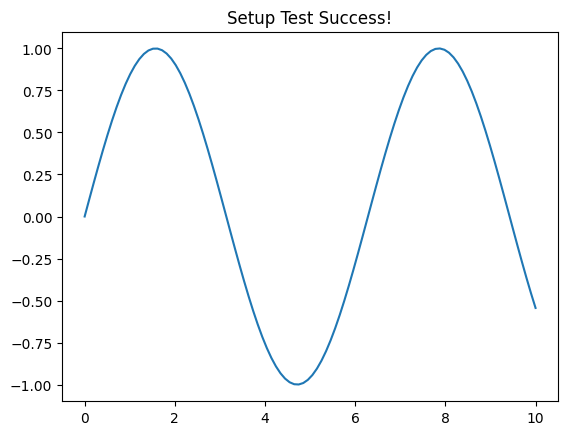

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Python version:", sys.version)
print("Allt fungerar!")

# Skapa en enkel graf för att testa bild-biblioteket
x = np.linspace(0, 10, 100)
y = np.sin(x)
plt.plot(x, y)
plt.title("Setup Test Success!")
plt.show()

In [1]:
# 5.1 & 5.2 Problem Setup + BFS
from collections import deque

graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': ['F'],
    'F': []
}

def bfs(graph, start, goal):
    queue = deque([[start]])
    visited = set()
    while queue:
        path = queue.popleft()
        node = path[-1]
        if node == goal: return path
        if node not in visited:
            visited.add(node)
            for neighbor in graph[node]:
                queue.append(list(path) + [neighbor])
    return None

print("BFS Path:", bfs(graph, 'A', 'F'))

BFS Path: ['A', 'C', 'F']


In [2]:
# 5.4 A* Search
import heapq

graph_cost = {'A': {'B': 1, 'C': 3}, 'B': {'D': 1, 'E': 3}, 'C': {'F': 5}, 'D': {}, 'E': {'F': 1}, 'F': {}}
heuristic = {'A': 5, 'B': 3, 'C': 4, 'D': 2, 'E': 1, 'F': 0}

def a_star(graph, heuristic, start, goal):
    queue = [(0, start, [start])]
    visited = set()
    while queue:
        (cost, node, path) = heapq.heappop(queue)
        if node == goal: return path
        if node not in visited:
            visited.add(node)
            for neighbor, weight in graph[node].items():
                total_cost = cost + weight + heuristic[neighbor]
                heapq.heappush(queue, (total_cost, neighbor, path + [neighbor]))
    return None

print("A* Path:", a_star(graph_cost, heuristic, 'A', 'F'))

A* Path: ['A', 'B', 'E', 'F']


In [3]:
# 5.6 Hill Climbing
import random

def f(x): return -x**2 + 10*x

def hill_climbing(start, step_size=1):
    current = start
    current_val = f(current)
    for _ in range(100):
        next_node = current
        next_val = current_val
        for n in [current - step_size, current + step_size]:
            if f(n) > next_val:
                next_node, next_val = n, f(n)
        if next_val <= current_val: break
        current, current_val = next_node, next_val
    return current, current_val

start_point = random.randint(-10, 10)
sol, val = hill_climbing(start_point)
print(f"Start: {start_point}, Topp: {sol}, Maxvärde: {val}")

Start: 1, Topp: 5, Maxvärde: 25


In [5]:
# 5.3 Depth-First Search (DFS)
def dfs(graph, start, goal):
    stack = [[start]] # Här är skillnaden! Stack istället för Queue
    visited = set()
    while stack:
        path = stack.pop() # Tar den SISTA vägen som lades till (LIFO)
        node = path[-1]
        if node == goal: return path
        if node not in visited:
            visited.add(node)
            for neighbor in graph[node]:
                stack.append(list(path) + [neighbor])
    return None

print("DFS Path:", dfs(graph, 'A', 'F'))

DFS Path: ['A', 'C', 'F']
